In [ ]:
#=nb

In [1]:
import torch
from torch import nn
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor, Normalize
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import PIL
from PIL import Image

In [40]:
path = os.listdir('data')
f'idx0 {path[0]},    idx1 {path[1]},    idx2 {path[2]},    idx3 {path[3]}'

'idx0 test_img.npy,    idx1 test_lbl.npy,    idx2 train_img.npy,    idx3 train_lbl.npy'

In [41]:
train_img = np.load(f'data//{path[2]}')
train_lbl = np.load(f'data//{path[3]}')
test_img = np.load(f'data//{path[0]}')
test_lbl = np.load(f'data//{path[1]}')

In [42]:
train_img.shape, train_lbl.shape, test_img.shape, test_lbl.shape

((10, 1, 6000, 28, 28), (1, 60000), (10, 1, 1000, 28, 28), (1, 10000))

In [48]:
train_img = train_img.reshape(-1, 28, 28) / 255
test_img = test_img.reshape(-1, 28, 28) / 255

In [74]:
train_img.shape, train_img[0].min(), train_img.max()

((60000, 28, 28), np.float64(0.1843137254901961), np.float64(1.0))

In [95]:
class Doodles(Dataset):
    def __init__(self, target, img, transform = None):
        self.target = target
        self.img = img
        self.transform = transform
    def __len__(self):
        return len(self.target)
    def __getitem__(self,idx):
        img = self.img[idx]
        lbl = torch.tensor(self.target[0][idx])
        if self.transform:
            img = self.transform(img)
        return (img.float(), lbl.int().item())

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [97]:
train_data = Doodles(train_lbl, train_img,ToTensor())
test_data = Doodles(test_lbl, test_img, ToTensor())

In [98]:
img,lbl = train_data[0]
img.min(), img.max(), lbl

(tensor(0.1843), tensor(1.), 0)

In [99]:
test_dataloader = DataLoader(test_data, batch_size = 256, shuffle = True)
train_dataloader = DataLoader(train_data, batch_size = 256, shuffle = True)

In [3]:
divice = ("cuda"
   if torch.cuda.is_available()
   else "mps"
   if torch.backends.mps.is_available()
   else "cpu")
divice

'cpu'

In [4]:
class ConvNet(nn.Module):
  def __init__(self):
    super(ConvNet, self).__init__()
    self.flatten = nn.Flatten()
    self.conv = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size= 3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2 , padding = 1),
        nn.Conv2d(32, 64, kernel_size= 3, padding = 1 ),
        nn.MaxPool2d(kernel_size = 2, stride = 2 , padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size= 2),
        nn.Conv2d(64, 64, kernel_size= 3, padding = 1 ),
        nn.ReLU(),
    )
    self.fc = nn.Sequential(
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
    )
  def forward(self, x):
    X = self.conv(x)
    X = self.flatten(X)
    X = self.fc(X)
    return X

      
model = ConvNet().to(divice)

In [102]:
x, y = next(iter(train_dataloader))
model(x).shape

torch.Size([1, 10])

In [103]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3, betas=(0.9, 0.999), eps= 1e-08, weight_decay = 0, amsgrad = False)

In [104]:
def train(model,dataloader, optimizer, loss_fn, print_every = 1):
  model.train()
  size = len(dataloader.dataset)
  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(divice), y.to(divice)
    pred = model(X)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % print_every == 0:
      current = (batch + 1) * len(X)
      print(f"loss: {loss.item():.4f},[Current: {current}/{size}]")


In [22]:
train(model , train_dataloader, optimizer,loss_fn, print_every = 100)

loss: 2.3032,[Current: 64/60000]
loss: 1.2101,[Current: 6464/60000]
loss: 1.0289,[Current: 12864/60000]
loss: 0.8003,[Current: 19264/60000]
loss: 0.8291,[Current: 25664/60000]
loss: 0.7883,[Current: 32064/60000]
loss: 1.1118,[Current: 38464/60000]
loss: 0.6702,[Current: 44864/60000]
loss: 1.0003,[Current: 51264/60000]
loss: 0.7854,[Current: 57664/60000]


In [105]:
def test(model, dataloader, loss_fn, print_every = 1):
  model.eval()
  num_batches = len(dataloader)
  test_loss, correct = 0 , 0
  with torch.no_grad():
    for X,y in dataloader:
      X,y = X.to(divice), y.to(divice)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= len(dataloader.dataset)
  print(f"Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [26]:
test(model,test_dataloader, loss_fn= loss_fn)

Accuracy: 74.8%, Avg loss: 0.770715 



In [106]:
epoches = 20
for t in range(epoches):
  print(f"Epoch {t+1}\n-------------------------------")
  train(model, train_dataloader, optimizer, loss_fn, print_every = 100)
  test(model, test_dataloader, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.3152,[Current: 1/1]
Accuracy: 0.0%, Avg loss: 2.281686 

Epoch 2
-------------------------------
loss: 2.2839,[Current: 1/1]
Accuracy: 0.0%, Avg loss: 2.217910 

Epoch 3
-------------------------------
loss: 2.1730,[Current: 1/1]
Accuracy: 100.0%, Avg loss: 2.111956 

Epoch 4
-------------------------------
loss: 2.0817,[Current: 1/1]
Accuracy: 100.0%, Avg loss: 1.936419 

Epoch 5
-------------------------------
loss: 1.7643,[Current: 1/1]
Accuracy: 100.0%, Avg loss: 1.672134 

Epoch 6
-------------------------------
loss: 1.5664,[Current: 1/1]
Accuracy: 100.0%, Avg loss: 1.280769 

Epoch 7
-------------------------------
loss: 1.2841,[Current: 1/1]
Accuracy: 100.0%, Avg loss: 0.774392 

Epoch 8
-------------------------------
loss: 0.3642,[Current: 1/1]
Accuracy: 100.0%, Avg loss: 0.291081 

Epoch 9
-------------------------------
loss: 0.1852,[Current: 1/1]
Accuracy: 100.0%, Avg loss: 0.054350 

Epoch 10
-------------------------------


In [26]:
torch.save(model.state_dict(), "model.pth")
print("model saved")

model saved


In [5]:
model = ConvNet().to(divice)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [28]:
classes = {
    0: "airpalne",
    1 : "alarm",
    2 : "ant",
    3 : "apple",
    4 : "arm",
    5 : "axe",
    6 : "bat",
    7 : "bed",
    8 : "birthday_cake",
    9 : "camera"
}

In [101]:
path = "C:\\Users\\pro\\Documents\\GitHub\\doodle\\img.json"

In [102]:
import json
with open(path , 'r') as f:
    data = json.load(f)

In [103]:
img = np.array(data['data'], dtype = np.uint8)

In [104]:
img.min(), img.max()

(np.uint8(63), np.uint8(255))

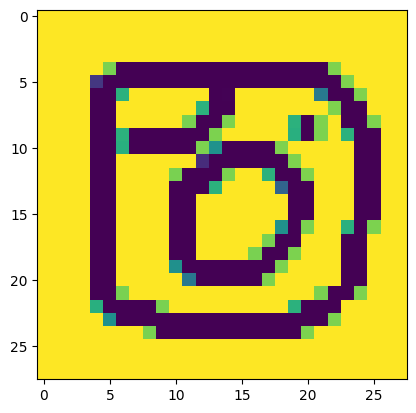

In [105]:
plt.imshow(img)

In [106]:
image = Image.fromarray(img)

In [107]:
image = transform(image)

In [108]:
image.shape, image.min(), image.max()

(torch.Size([1, 28, 28]), tensor(-0.5059), tensor(1.))

In [109]:
image = image.reshape(1,1,28,28)

In [110]:
classes[model(image).argmax(1).item()]

'camera'